In [ ]:
computer = 'micha' # XPS17

import specutils
import numpy as np
import pandas as pd
import statistics as st
import scipy

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import LogNorm
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import AutoMinorLocator

from astropy.io import fits
from astropy import units as u
from astropy import constants as const
from astropy.visualization import quantity_support
quantity_support()
import astropy.utils.compat
from astropy.modeling import models
from astropy.nddata import StdDevUncertainty

from specutils import Spectrum1D
from specutils.analysis import line_flux
from specutils import Spectrum1D, SpectralRegion
from specutils.manipulation import extract_region
from specutils.fitting import fit_generic_continuum

from astropy.convolution import Gaussian2DKernel, interpolate_replace_nans

######################################### creating files below ####################################################

c_u = (const.c.value *1e6) *(u.micron/u.s)   # units = [um/s]
#CO_file = '/Users/'+computer+'/Dropbox/Michael_Sanchez_project/COCO.xlsx' # Contains CO RoVib wavelengths
CO_file = '/Users/'+computer+'/Google Drive/Research;/Banzatti/Michael_Sanchez_project/COCO.xlsx'

flhead = ['RULup_M_APR07', 'AATau_M','CVCha_M','DFTAU_M','DoAr44_M_SEP07','DRTau_M_DEC08','EXLup14_M','HD135344B_M_APR07',
          'HD142527_M_5AUG08','HD144432S_M','TWHya_M','RYLup_M_APR07','HD36112_ISHELL','TWCha_M_JAN09','HD139614_Carmona',
          'HD31293_ISHELL','HD31648_ISHELL']
errhead = ['RULup_M_APR07_err','AATau_M_err','CVCha_M_err','DFTAU_M_err','DoAr44_M_SEP07_err','DRTau_M_DEC08_err',
           'EXLup14_M_err','HD135344B_M_APR07_err','HD142527_M_5AUG08_err','HD144432S_M_err','TWHya_M_err',
           'RYLup_M_APR07_err','HD36112_ISHELL_err','TWCha_M_JAN09_err','HD139614_Carmona_err','HD31293_ISHELL_err',
           'HD31648_ISHELL_err']
heads = flhead + errhead
COlines_table = pd.read_excel(CO_file, sheet_name="COlineranges")     # excel sheet in which info is contained
#testf = [['/Users/temprecover/Dropbox/Michael_Sanchez_project/DATA/'+flhead+'.fits'],
#         ['/Users/temprecover/Dropbox/Michael_Sanchez_project/DATA/stacked_lines/RULup_COv1-0stacked.fits']]
#print(testf)
########################################## opening files below ####################################################

# .fits files defined as ffile[0] & ffile[1] for data and stacked line profiles, respectively.

#still = '/Users/'+computer+'/Dropbox/Michael_Sanchez_project/DATA/'
still = '/Users/'+computer+'/Google Drive/Research;/Banzatti/Michael_Sanchez_project/DATA/'
ffile = [
        [still + 'RULup_M_APR07.fits',     #     [ 0 ]
         still + 'AATau_M.fits',           #     [ 1 ]
         still + 'CVCha_M.fits',           #     [ 2 ]
         still + 'DFTAU_M.fits',           #     [ 3 ]
         still + 'DoAr44_M_SEP07.fits',    #     [ 4 ]
         still + 'DRTau_M_DEC08.fits',     #     [ 5 ]
         still + 'EXLup14_M.fits',         #     [ 6 ]
         still + 'HD135344B_M_APR07.fits', #     [ 7 ]
         still + 'HD142527_M_5AUG08.fits', #     [ 8 ]
         still + 'HD144432S_M.fits',       #     [ 9 ]
         still + 'TWHya_M.fits',           #    [ 10 ]
         still + 'RYLup_M_APR07.fits',     #    [ 11 ]
         still + 'HD36112_ISHELL.fits',    #    [ 12 ]
         still + 'TWCha_M_JAN09.fits',     #    [ 13 ]
         still + 'HD139614_Carmona.fits',  #    [ 14 ]
         still + 'HD31293_ISHELL.fits',    #    [ 15 ]
         still + 'HD31648_ISHELL.fits'],   #    [ 16 ]

        [still + 'stacked_lines/RULup_COv1-0stacked.fits',     #     [ 0 ]
         still + 'stacked_lines/AATau_COv1-0stacked.fits',     #     [ 1 ]
         still + 'stacked_lines/CVCha_COv1-0stacked.fits',     #     [ 2 ]
         still + 'stacked_lines/DFTAU_COv1-0stacked.fits',     #     [ 3 ]
         still + 'stacked_lines/DoAr44_COv1-0stacked.fits',    #     [ 4 ]
         still + 'stacked_lines/DRTau_COv1-0stacked.fits',     #     [ 5 ]
         still + 'stacked_lines/EXLup14_COv1-0stacked.fits',   #     [ 6 ]
         still + 'stacked_lines/HD135344B_COv1-0stacked.fits', #     [ 7 ]
         still + 'stacked_lines/HD142527_COv1-0stacked.fits',  #     [ 8 ]
         still + 'stacked_lines/HD144432S_COv1-0stacked.fits', #     [ 9 ]
         still + 'stacked_lines/TWHya_COv1-0stacked.fits',     #    [ 10 ]
         still + 'stacked_lines/RYLup_COv1-0stacked.fits',     #    [ 11 ]
         still + 'stacked_lines/HD36112_COv1-0stacked.fits',   #    [ 12 ]
         still + 'stacked_lines/TWCha_COv1-0stacked.fits',     #    [ 13 ]
         still + 'stacked_lines/HD139614_COv1-0stacked.fits',  #    [ 14 ]
         still + 'stacked_lines/HD31293_COv1-0stacked.fits',    #    [ 15 ]
         still + 'stacked_lines/HD31648_COv1-0stacked.fits']    #    [ 16 ]
        ]

#defining column headers to create Pandas dataframe object

############################ Isolating columns from excel spreadsheet: COlines_table #############################
COv = COlines_table['vib']
COb = COlines_table['branch']
coo = np.where( (COv=='v1-0') & (COb=='P') )
P   = coo[0]
COl = COlines_table['line'][P].reset_index()['line']
COw = COlines_table['wl'][P].reset_index()['wl']

fluxdf = pd.DataFrame(columns=heads, index=COl)  # Dataframe object to be filled with line fluxes & their error

for y in range(len(heads)):
    fluxdf[heads[y]] = np.repeat(0., len(P))         # Populating each column with 0's to fill in later.

print("\n IT IS DONE, SERVANT. FETCH ME MORE DATA \n")#,fluxdf[heads[:5]][35:])


 IT IS DONE, SERVANT. FETCH ME MORE DATA 



In [ ]:
###### from astropy.modeling.polynomial import Chebyshev1D
from specutils.fitting import fit_lines
from matplotlib.backends.backend_pdf import PdfPages
from specutils.analysis import fwzi
from scipy.signal import find_peaks, peak_widths
import datetime
from pandas import ExcelWriter


win  = 5.2e-4       # range within continuum values will be measured/fitted
cont = 1.95e-3      # distance from central line at which 'win' will begin
diskinds = []         # Stores the indexes used per disk.
chi_table = []      # Stores scale & chi^2
specRes = [[],[]]
mp_fwzi = pd.ExcelWriter(datetime.datetime.now().strftime("%b"+"%d")+'_model_input.xlsx', engine='xlsxwriter')
#writer = pd.ExcelWriter('JUL_lineboundaries_CO.xlsx', engine='xlsxwriter')
#pdf_disks = PdfPages('2020-05-22 Pline_v_Flux.pdf')
#pdf_spectra = PdfPages('2020-05-22 Disk Spectra.pdf')

# Funkies
## wave2vel():
 - input: wavelength linewidth IN MICRONS
 - output: velocity line width IN KM/S

## vel2wav():
 - input: velocity line width IN KM/S
 - output: wavelength linwidth IN MICRONS

## best_fit1d():
 This function was meant for Spectrum1D() objects
  - must be optimized for a more general approach

In [ ]:
###############################################################################################################
def wav2vel(LINE_WIDTH, REST_WAVELENGTH, LINE_VELOCITY_WIDTH=None): # vel in km/s, wv in um
    velocity = ((LINE_WIDTH/REST_WAVELENGTH)-1)*const.c.value*1e-3 # converting data wv to vel. then resampled
    if LINE_VELOCITY_WIDTH is not None:
        vel_mask = (min(LINE_VELOCITY_WIDTH)<velocity)&(velocity<max(LINE_VELOCITY_WIDTH))
        velos = velocity[vel_mask]
        return velocity, vel_mask, velos
    elif LINE_VELOCITY_WIDTH is None:
        return velocity
###############################################################################################################
def vel2wav(LINE_VELOCITY_WIDTH, REST_WAVELENGTH, LINE_WIDTH=None): # vel in km/s, wv in um
    st_wav = ((LINE_VELOCITY_WIDTH/(const.c.value*1e-3))+1)*REST_WAVELENGTH
    if LINE_WIDTH is not None:
        m_mask = (min(st_wav)<LINE_WIDTH)&(LINE_WIDTH<max(st_wav))
        return st_wav, m_mask, st_wav[m_mask[0]]
    elif LINE_WIDTH is None:
        return st_wav
###############################################################################################################
def best_fit1d(LINE_FLUX_DENSITY, CONT_FIT, RESAMPLED_WV, FLUX_ERROR):#, SUBSPEC1D_OBJ):
    scale = np.arange(0,2.75,0.01)
    chi_list = []
    for l in scale:
        chi_2 = np.nansum(((LINE_FLUX_DENSITY-CONT_FIT)-(l*RESAMPLED_WV))**2*
                          (FLUX_ERROR**(-2)) )
        chi_list.append(chi_2)
    min_chi = chi_list[np.where(min(chi_list)==chi_list)[0][0]]
    bestmodelfluxes = scale[np.where(min(chi_list)==chi_list)[0][0]] * RESAMPLED_WV
    scale_chi.append([scale[0],chi_list])
    #bestmodelspectra = Spectrum1D(flux=(bestmodelfluxes+CONT_FIT[MOD_MASK])*u.Jy,
    #                    spectral_axis=SUBSPEC1D_OBJ.spectral_axis[MOD_MASK])
    return bestmodelfluxes, chi_list, scale_chi#, bestmodelspectra
###############################################################################################################
def line_profile(master_s1d, dat_wav,dat_flux,l_bound,r_bound,left_line,right_line): # master_s1d = Spectrum1D()
    line_ind = np.where(np.logical_and(master_s1d.spectral_axis.value>=l_bound,
                                        master_s1d.spectral_axis.value<=r_bound))
    line_mask = (master_s1d.spectral_axis > left_line*u.micron)&(master_s1d.spectral_axis <
                                                                    right_line*u.micron)
    #datline_mask = (dat_wav[pline_ind] > left_line) & (dat_wav[pline_ind] < right_line)
    wav_pind = dat_wav[line_ind]
    flux_pind = dat_flux[line_ind]
    #sub_ms1d = Spectrum1D(flux=master_s1d.flux[pline_ind], spectral_axis=master_s1d.spectral_axis[pline_ind],
    #                     uncertainty=master_s1d.uncertainty[pline_ind])
    return line_mask, wav_pind, flux_pind, line_ind #datline_mask, sub_ms1d,
###############################################################################################################
def continuum_fit(SUB_SPECTRUM1D, CONT_MASK, SPEC_UNCERT):
    p_fit = np.polyfit(SUB_SPECTRUM1D.spectral_axis.value[CONT_MASK],
                       SUB_SPECTRUM1D.flux.value[CONT_MASK], deg=1, w=(SPEC_UNCERT[CONT_MASK])**(-2),
                       cov='unscaled') # cov=unscaled means our uncertainties are reliable.
    a_err = np.sqrt(np.diag(p_fit[1])[1]) # stdev a
    b_err = np.sqrt(np.diag(p_fit[1])[0]) # stdev b
    y_cont_fit = (p_fit[0][0]*sub_spec.spectral_axis.value) + p_fit[0][1] # y=bx+a Continuum Fit
    cont_err = np.sqrt((a_err**2) + (sub_spec.spectral_axis.value*(b_err))**2) # Jansky
    return y_cont_fit, cont_err
###############################################################################################################

# PRINT LINES
## Print lines within a disk

/Users/micha/Google Drive/Research;/Banzatti/Michael_Sanchez_project/DATA/HD139614_Carmona.fits
4e-05
0 P1
1 P2
2 P3
3 P4
4 P5
5 P6
['P12']


(0.925, 1.35)

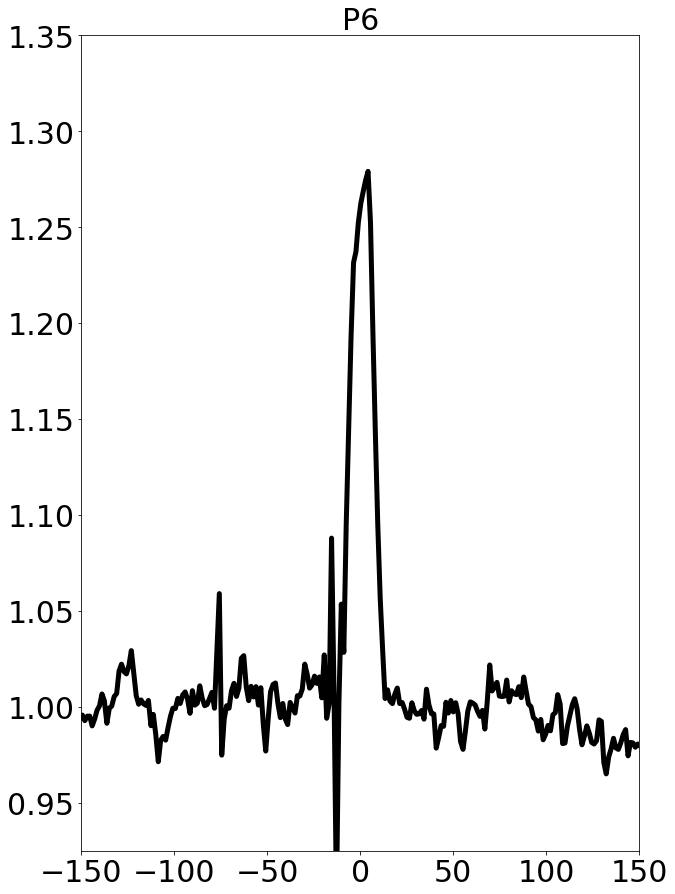

In [ ]:
#0 - RU Lupi     # 6 - EX Lupi      # 12 - HD36112
# 1 - AA Tauri    # 7 - HD135344B    # 13 - TW Cha
# 2 - CV Cha      # 8 - HD142527     # 14 - HD139614
# 3 - DF Tauri    # 9 - HD144432S    # 15 - HD31293
# 4  - DO Ar44    # 10 - TW Hydrae   # 16 - HD31648
# 5  - DR Tauri   # 11 - RY Lupi

d_i = 14

flux_df = pd.read_excel('Sep30_model_input.xlsx', sheet_name=flhead[d_i])
df_line = flux_df['line'].to_numpy()
rest_wav = flux_df['wavelength'].to_numpy()
lam_min = flux_df['lammin'].to_numpy()
lam_max = flux_df['lammax'].to_numpy()
line_flux = flux_df['flux'].to_numpy()
print(ffile[0][d_i])#,'\n',flux_df)

############     Velocity Shift per disk
offset = pd.read_excel('Sep30_model_input.xlsx', sheet_name='Disk Res')['offset'].to_numpy()[d_i]
COw_n = COw.to_numpy()
COl_n = COl.to_numpy()

############    CO SPECTRAL DATA: (um,Jy)
specdata = fits.open(ffile[0][d_i])[1].data[0]   # opens .fits files
fits.open(ffile[0][d_i]).close()
wv  = specdata[0]*1e-3         # converting to micron from nm
fln = specdata[1]
err = StdDevUncertainty(specdata[2], unit = 'Jy')
m_spec = Spectrum1D(flux=fln*u.Jy, spectral_axis=wv*u.micron, uncertainty=err)

############    STACKED LINE PROFILE (ks/s, um, Jy)
stackdata = fits.open(ffile[1][d_i])[1].data[0]
fits.open(ffile[1][d_i]).close()
vel = stackdata[0] # km/s
flx = stackdata[1]
errr = stackdata[2]
yfitt = stackdata[3]

###########################################################################################################

v_d = pd.read_excel('Sep30_model_input.xlsx', sheet_name='Disk Res')
v_shift = v_d['offset'][d_i]
print(v_shift)

#for wren in range(15):
#    disk_prop = pd.read_excel('Sep30_model_input.xlsx', sheet_name=flhead[wren])

index = 5
for dex in flux_df.index[0:6]:
    print(dex, COl_n[dex])

lll = np.where(df_line[index] == COl_n)[0]
st_wav = vel2wav(vel,COw_n[lll])

print(COl_n[lll])

v_wav = wav2vel(wv - v_shift, COw_n[lll])
vel_min = wav2vel(lam_min[index],COw_n[lll])
vel_max = wav2vel(lam_max[index],COw_n[lll])
v_offset = wav2vel(COw_n[lll]+offset,COw_n[lll])


#if np.any(abs(np.isinf(sub_spec.flux))) == True:
#    sub_spec.flux[np.where(np.isinf(sub_spec.flux))] = np.nan
#if np.any(abs(np.isinf(flnp))) == True:
#    flnp[np.where(np.isinf(flnp))] = np.nan

ghost = plt.figure(figsize=(10,15))
plt.plot(v_wav, fln, linewidth=5.0, color='black')
plt.title(COl_n[index], fontsize=30)
#plt.axvline(COw[lll], color='red')
#plt.axvline(v_offset, color='red', linestyle='-.')
#plt.axvline(vel_min, color='black', linestyle='-.')
#plt.axvline(vel_max, color='black', linestyle='-.')
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlim(-150, 150)
plt.ylim(.925,1.35)
#plt.savefig('Line '+COl_n[index]+'-'+flhead[d_i]+'_single.png', bbox_inches='tight')

In [ ]:
import os
os.system("/Users/"+computer+"/Google Drive/Research;/Banzatti/tar_sanchez/ir_model")
#os.system("/Users/sancheezy/Google Drive/Research;/Banzatti/tar_sanchez/ir_model")
from ir_model_ms import *
from scipy.optimize import fmin
import openpyxl
from herramientas import readspecs as rs

mol_data = MolData("CO","hitran_data/co_hitran12.par")
intensity = Intensity(mol_data)
mp = 'Sep30_model_input.xlsx' # READ

# _________________ WRITE _________________
fi = 5
nom_fi = "modgrid_"+flhead[fi]+".xlsx"
# _________________ READ __________________
fitsfi = '/Users/'+computer+'/Dropbox/Michael_Sanchez_project/DATA/'+flhead[fi]+'.fits'
mp_fi = pd.read_excel(mp, sheet_name=flhead[fi]) # READ
ch = pd.read_excel(mp, sheet_name='Disk Res')
Rtot = ch.loc[fi,'R_tot']
Rf   = ch.loc[fi,'R_fif']
n_el = len(mp_fi['flux']) # len(number of elements of line fluxes)
dof = 3                   # number of model parameters (T, n, r)
###readcsv = pd.read_csv('HD36112_COlinefluxes_v1-0_4fit_LARGERRORS.csv', skiprows=2,
#                      names=["lammin", "lammax", "flux", "flux_error"])
RC = Rf                     # Spectral Resolution to use

chi2_spec = Chi2Spectrum()
chi2_spec.load_file(mp_fi, form='s')
#chi2_spec.load_file('HD36112_COlinefluxes_v1-0_4fit_LARGERRORS.txt', form='original')


print('disk number = ', fi, '\n disk = ', flhead[fi],
      '\n number of elements = ', n_el, '\n deg of freedom = ', dof)
print('Spectral Resolution (R_all, R_15, RC) =',(Rtot,Rf,RC))

############################################################################################################

def yfunc(data_fluxes, freq, A_UL, G_UP):
    top = (4*np.pi*data_fluxes)
    bottom = (const.h*freq*A_UL*G_UP)
    return np.log10(top/bottom)

def compare_plot(x1,y1,x2,y2,xl1,xl2,yl1,yl2,**pwargs):
    spmod = plt.figure(figsize=(40,10))
    plt.plot(x1,y1,**pwargs)
    plt.plot(x2,y2, **pwargs)
    plt.ylim(yl1,yl2)
    plt.xlim(xl1,xl2)
    return(spmod)

CO_params =np.loadtxt('/Users/'+computer+'/Dropbox/Michael_Sanchez_project/Rotation_Diagram/CO_lines_params.dat',
                      skiprows=8, usecols=(2,3,4,5,6,7))
COconst = pd.DataFrame(data=CO_params,columns=['Lambda [um]', 'Tau', 'Intensity[er/s/cm2/sr]',
                                               'A_ul', 'E_up', 'g_up'])

PP = []                     # To be filled with index values for CO_lines_params.dat -> 42 in total

for a in range(len(P)):
    bot=np.where(round(COw[a],6)==COconst['Lambda [um]'])[0] # wv indexes for constants in COconst df
    PP.append(bot[0])

COconsts = pd.DataFrame(data=CO_params[PP],columns=COconst.columns)
lamda = COconsts['Lambda [um]']
A_ul = COconsts['A_ul']
E_up = COconsts['E_up']
g_up = COconsts['g_up']
COf = pd.DataFrame(data=c_u/COw)

disk number =  5 
 disk =  DRTau_M_DEC08 
 number of elements =  15 
 deg of freedom =  3
Spectral Resolution (R_all, R_15, RC) = (17607.94575833263, 17691.6569368419, 17691.6569368419)


In [ ]:
datax = rs.Unpack(fits_fname=fitsfi)._wavelength-offset
datay = rs.Unpack(fits_fname=fitsfi)._fluxd-1.
modelx = test_spectrum_fi.lam
modely = test_spectrum_fi.flux_jy
'''
mxx=modelx
myy=modely
df_key = df_fi
test_key = test_spectrum_fi


rots=plt.figure(figsize=(40,10))
plt.grid(True)
plt.plot(xx,yy,'+')
plt.title(flhead[fi])
plt.plot(xx,myy, label='t_kin='+str(rest['t_kin'][0])+', n_mol='+"{:e}".format(rest['n_mol'][0])+
         ', radius='+str(rest['radius'][0])+', $\chi^2_{reduced}$ ='+str(sum(df_key['chi2']/35.)))
#plt.plot(xx,mmyy, label='t_kin='+str(v_temp)+', n_mol='+"{:e}".format(v_n)+
#         ', radius='+str(rad)+', $\chi^2_{reduced}$ ='+str(coupe[1]/35.))
plt.legend()
yerr = (0.434 * (df_key['flux_error']/df_key['flux']))
plt.errorbar(xx, yy, yerr=yerr,fmt=' ', ms=10)
plt.xlim(3000,9000)
ylo = min([min(yy),min(myy)])#,min(mmyy)])
yhi = max([max(yy),max(myy)])#,max(mmyy)])

plt.ylim(ylo,yhi)
plt.xlabel('E_up [K]')
plt.ylabel('ln(4 $\\pi$ F / h $\\nu$ $A_{ul}$ $g_u$)')
for k in ds:
    plt.annotate(COl[k], (xx[k],yy[k]), textcoords="offset points", xytext=(0,10), ha='center')
plt.show()'''

# ds -> np.array that locates (indexes) wavelengths and lines used from COw & COl; depends on df_fi
ds = []
for cake in df_fi['line']:
    ds.append((np.where(COl==cake)[0][0]))

rest_wave = COw[ds].to_numpy()
rest_line = COl[ds].to_numpy()
print(rest_wave, '\n', rest_line)

lop,lob = int(.25*len(ds)), int(.25*len(datay))
mip,mib = int(.5*len(ds)),  int(.5*len(datay))
hip,hib = int(.75*len(ds)), int(.75*len(datay))
#def y_const(loq, hiq):
#    ycst = np.nanmedian(datay[loq:hiq]) # hopefully yields a number close to "continuum" fluxd level.
#    return ycst
ylimlo = -.2
ylimhi = np.nanmax([max(datay),max(modely)]) #.5
txh = -.1

mon = np.where(np.logical_and(rest_wave>4.65,rest_wave<4.75))[0]
tue = np.where(np.logical_and(rest_wave>4.75,rest_wave<4.85))[0]
wed = np.where(np.logical_and(rest_wave>4.85,rest_wave<4.95))[0]
thu = np.where(np.logical_and(rest_wave>4.95,rest_wave<5.2))[0]
print(mon,tue,wed,thu)
p1 = compare_plot(datax,datay,modelx,modely,4.65,4.75,ylimlo,ylimhi)
p2 = compare_plot(datax,datay,modelx,modely,4.75,4.85,ylimlo,ylimhi)
p3 = compare_plot(datax,datay,modelx,modely,4.85,4.95,ylimlo,ylimhi)
p4 = compare_plot(datax,datay,modelx,modely,4.95,5.2,ylimlo,ylimhi)

# Print Entire Spectra

In [ ]:
diskname = 'TW Hya'

sp_fig = plt.figure(figsize=(50,10))
plt.title(diskname, fontsize=30, pad=20)
#plt.grid(True)
plt.plot(wv, fln, color='black', label='CO data')

CO_emission = pd.read_table('/Users/'+computer+
                            '/Google Drive/Research;/Banzatti/Michael_Sanchez_project/COlineranges.txt',usecols=(0,1,2))
emission_wl = CO_emission['wl'].to_numpy()
emission_line = CO_emission['line'].to_numpy()

v1   = np.where(CO_emission['vib'].to_numpy()=='v1-0')[0]
v2   = np.where(CO_emission['vib'].to_numpy()=='v2-1')[0]
CO13 = np.where(CO_emission['vib'].to_numpy()=='13CO')[0]

#plt.vlines(emission_wl[v1], 0, 3., colors='red', linestyles='--', label='v=1-0')
#plt.vlines(emission_wl[v2], 0, 3., colors='magenta', linestyles='-.', label='v=2-1')
#plt.vlines(emission_wl[CO13], 0, 3., colors='gray', linestyles='dotted',label='$^{13}$CO')

#for w in np.arange(20)[11+10:15+10]:
#    plt.text(x=emission_wl[v1][w], y=0.85, s=emission_line[v1][w], fontsize=20)
#for b in np.arange(20)[11:16]:
#    plt.text(x=emission_wl[v2][b], y=0.85, s=emission_line[v2][b], fontsize=20)
#for d in np.arange(20)[14:18]:
#    plt.text(x=emission_wl[CO13][d], y=0.85, s=emission_line[CO13][d], fontsize=20)

#plt.legend(fontsize=30, frameon=True, loc='upper left')
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel('Wavelength [$\mu$m]', labelpad=20, fontsize=30)
plt.ylabel('Normalized Flux [Jy]', labelpad=20, fontsize=30)
plt.xlim(min(wv)-.005,max(wv)+.005 )
plt.ylim(-.15, 2.95)
#plt.savefig(diskname+' full spectra figure.png', bbox_inches='tight')

# Printing CO Spectra from Banzatti for LTE RD Figure

/Users/micha/Google Drive/Research;/Banzatti/Pypes/CO_models_Banzatti/1500k_116cm_1au/spectrum.csv


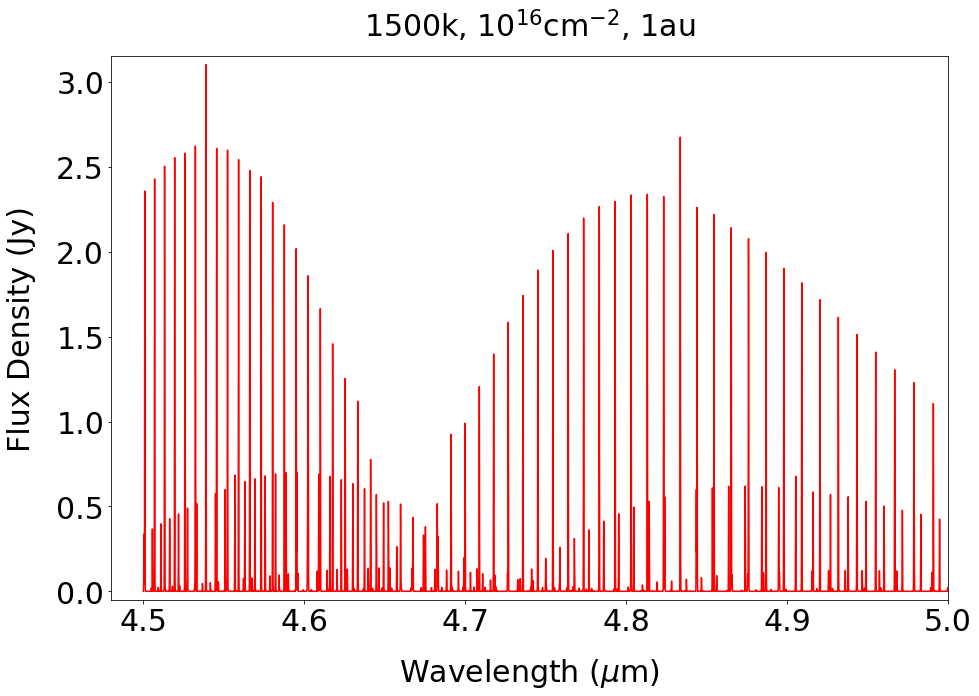

In [ ]:
rdfolder = '/Users/'+computer+'/Google Drive/Research;/Banzatti/Pypes/CO_models_Banzatti/'
temps = ['300k','600k','1000k','1500k']
dens = ['116cm','117cm','118cm','119cm']
nams = ['10$^{16}$cm$^{-2}$','10$^{17}$cm$^{-2}$','10$^{18}$cm$^{-2}$','10$^{19}$cm$^{-2}$']

k = 3
n = 0
isotherm = (rdfolder+temps[k]+'_'+dens[n]+'_1au/spectrum.csv')
print(isotherm)
spectrum_df = pd.read_csv(isotherm)
rdx = spectrum_df['lam']
rdy = spectrum_df['flux_jy']


synfig = plt.figure(figsize=(15,10))
plt.title(temps[k]+', '+nams[n]+', 1au', fontsize=30, pad=20)
plt.plot(rdx, rdy, color='red')#, label='300K')
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel('Wavelength ($\mu$m)', labelpad=20, fontsize=30)
plt.ylabel('Flux Density (Jy)', labelpad=20, fontsize=30)
plt.xlim(4.48,5)
plt.ylim(min(rdy)-5e-2, max(rdy)+5e-2)
plt.savefig('CO synthetic '+temps[k]+' '+dens[n]+'.png', bbox_inches='tight')

# Print Spectral Region

In [ ]:
from astroquery.simbad import Simbad
result_table = Simbad.query_object("TW Hya", "TW Cha")
print(result_table)

C:\ProgramData\Anaconda3\lib\site-packages\astroquery\simbad\core.py:135: UserWarning: Warning: The script line number 3 raised an error (recorded in the `errors` attribute of the result table): Identifier not found in the database : ^TW +Hya$
  warnings.warn("Warning: The script line number %i raised "


None


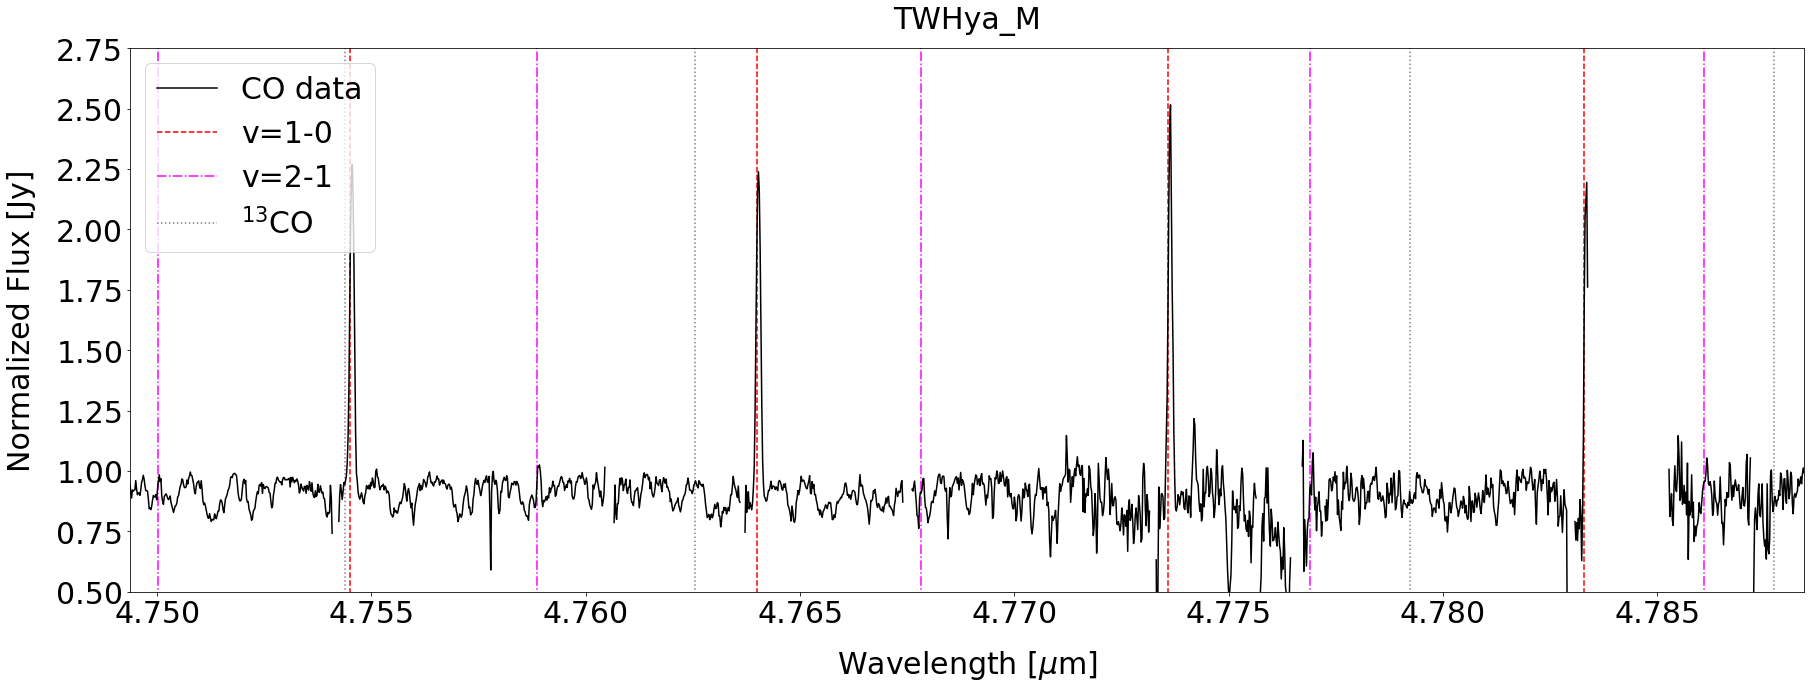

In [ ]:
sp_fig = plt.figure(figsize=(30,10))
plt.title(flhead[d_i], fontsize=30, pad=20)
#plt.grid(True)
plt.plot(wv, fln, color='black', label='CO data')

CO_emission = pd.read_table('/Users/'+computer+
                            '/Google Drive/Research;/Banzatti/Michael_Sanchez_project/COlineranges.txt',usecols=(0,1,2))
emission_wl = CO_emission['wl'].to_numpy()
emission_line = CO_emission['line'].to_numpy()

v1   = np.where(CO_emission['vib'].to_numpy()=='v1-0')[0]
v2   = np.where(CO_emission['vib'].to_numpy()=='v2-1')[0]
CO13 = np.where(CO_emission['vib'].to_numpy()=='13CO')[0]

plt.vlines(emission_wl[v1], 0, 3., colors='red', linestyles='--', label='v=1-0')
plt.vlines(emission_wl[v2], 0, 3., colors='magenta', linestyles='-.', label='v=2-1')
plt.vlines(emission_wl[CO13], 0, 3., colors='gray', linestyles='dotted',label='$^{13}$CO')

#for w in np.arange(20)[11+10:15+10]:
#    plt.text(x=emission_wl[v1][w], y=0.85, s=emission_line[v1][w], fontsize=20)
#for b in np.arange(20)[11:16]:
#    plt.text(x=emission_wl[v2][b], y=0.85, s=emission_line[v2][b], fontsize=20)
#for d in np.arange(20)[14:18]:
#    plt.text(x=emission_wl[CO13][d], y=0.85, s=emission_line[CO13][d], fontsize=20)

plt.legend(fontsize=30, frameon=True, loc='upper left')
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel('Wavelength [$\mu$m]', labelpad=20, fontsize=30)
plt.ylabel('Normalized Flux [Jy]', labelpad=20, fontsize=30)
plt.xlim(lam_min[9]-.005,lam_max[12]+.005 )
plt.ylim(.5, 2.75)
#plt.savefig(flhead[d_i]+' emission lines figure.png', bbox_inches='tight')

# Line Protocol Pipeline
## Only needs first 3 cells to activate

/Users/micha/Google Drive/Research;/Banzatti/Michael_Sanchez_project/DATA/RULup_M_APR07.fits
R_fwzi = 1634.3185314684831 
 R_fwhm 12237.098578492487 
 R_fwhm <=15 12205.134937269502
RULup_M_APR07 end
The end.


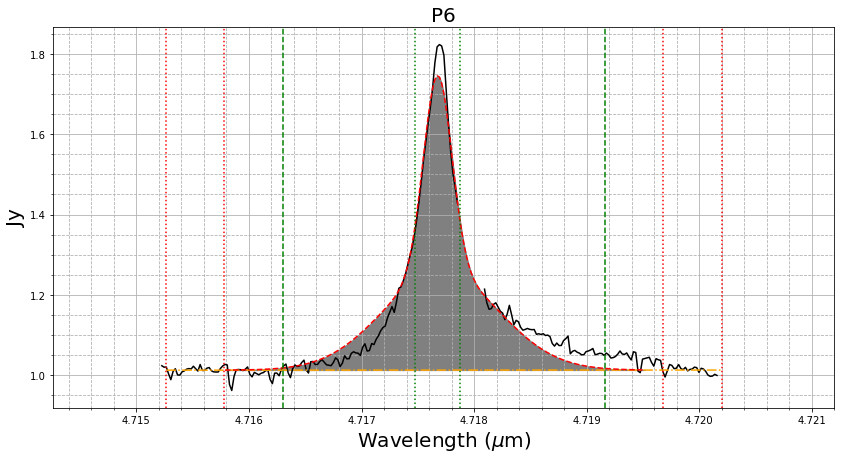

In [ ]:


for f in range(len(ffile[0]))[0:1]:
    print(ffile[0][f])
    #
    specdata = fits.open(ffile[0][f])[1].data[0]   # opens .fits files
    fits.open(ffile[0][f]).close()
    wv  = specdata[0]*1e-3         # converting to micron from nm
    fln =(specdata[1])
    err = StdDevUncertainty(specdata[2], unit = 'Jy')
    m_spec = Spectrum1D(flux=fln*u.Jy, spectral_axis=wv*u.micron, uncertainty=err)

    flux_col = []
    flerr_col = []
    ind_used = []
    scale_chi = []
    modpar_fwzi = [[],[],[],[],[],[]]
    R_fwhm = [[],[]]
    lin_bound = [[],[],[],[],[],[],[]]
    #offset=pd.read_excel('/Lines Master Tables/JUL_lineboundaries_CO.xlsx', sheet_name='sheet_offset').loc[f,'Offset']

    disk_f = {flhead[0]:4e-5,flhead[1]:1e-4,flhead[2]:0.0,flhead[3]:2e-4,flhead[4]:1.5e-4,flhead[5]:1.8e-4,
             flhead[6]:0.0,flhead[7]:1.2e-4,flhead[8]:1e-4,flhead[9]:5e-5,flhead[10]:4.5e-5,flhead[11]:6e-5,
             flhead[12]:-1.6e-4,flhead[13]:1e-4,flhead[14]:4e-5,flhead[15]:-1.5e-4,flhead[16]:-1.5e-4}

#    quaker = pd.DataFrame.from_dict(data=disk_f, orient='index', columns=['Offset'])
#    quaker.to_excel(writer, sheet_name='sheet_offset')
    offset = 0.
    if f == 0:    # RULup
        offset = 4e-5
    elif f== 1:   # AATau
        offset = 1e-4
    elif f== 3:   # DFTau
        offset = 2e-4
    elif f== 4:   # DoAr
        offset = 1.5e-4
    elif f== 5:   # DRTau
        offset = 1.8e-4
    elif f== 7:   # HD-44B
        offset = 1.2e-4
    elif f== 8:   # HD-2527
        offset = 1e-4
    elif f== 9:   # HD-32S
        offset = 5e-5
    elif f== 10:  # TWHya
        offset = 4.5e-5
    elif f== 11:  # RYLup
        offset = 6e-5
    elif f== 12:  # HD-112 ISHELL
        offset = -1.6e-4
    elif f== 13:  # TWCha
        offset = 1e-4
    elif f== 14:  # HD-9614
        offset = 4e-5
    elif f==15:
        offset = -1.5e-4
    elif f==16:
        offset = -1.5e-4

    stackdata = fits.open(ffile[1][f])[1].data[0]
    fits.open(ffile[1][f]).close()
    vel = stackdata[0] # km/s
    flx = stackdata[1]
    errr = stackdata[2]
    yfitt = stackdata[3]
    '---------------------------------- PDF EXPORT/SAVE ATTEMPT 1 ----------------------------------------'
#    pdf_lines = PdfPages('P_lines_'+flhead[f]+'.pdf')
    #
    for i in range(len(P)):
        #
        'OFFSET -------|-------'
        CO_w = COw[i] + offset

        ' GLOBAL CONTINUUM BOUNDARY ASSIGNMENTS  --------[-]--^--[-]--'

        ileft = CO_w - cont
        left = ileft - win
        iright = CO_w + cont
        right = iright + win

        ' SPECTRA BOUNDARIES  [--^-^-^^--^-^-^^--^-] '

        if CO_w < min(m_spec.spectral_axis.value):
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        elif CO_w > max(m_spec.spectral_axis.value):
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        elif f==14 and i>=15: # CARMONA SPECTRA CLIPPING. STOPS AT P15
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue

        ' GLOBAL LINE BOUNDARY ASSIGNMENTS  ------------[-^-]----'
        ' CONTINUUM/LINE BOUNDARY SHIFTS  ----[-]--_-[-^]-[-]------'
        ' Individual Continuum/Line Boundary Shifts... '

        k = cont/win               # k = 3.75 -n
        l_line = CO_w - (k-1)*win  # k = 2.75 for original line boundary value, k-1
        r_line = CO_w + (k-1)*win  # (k-1)*win.value= cont - win.value

        if f==0:   #RULup
            thr, fou = l_line-offset, r_line-offset

            if i == (2)-1: # 'P2'
                l_line = CO_w - 1.75*win
            elif i == (3)-1:
                r_line = CO_w + cont - 1.5*win
            elif i == (5)-1: # P5
                l_line = CO_w - 1.75*win
                #ileft...
                left = ileft - win
            elif i == (7)-1: # P7
                r_line = CO_w + 2.55*win
                iright = CO_w + cont + 0.5*win
                right = iright + win
            elif i == (9)-1: # P9
                r_line = CO_w + (k-2)*win
            elif i == (13)-1: # P13
                iright = CO_w + 2*cont
                right = iright + win
            elif i == (14)-1: # P14
                iright = CO_w + 0.95*cont
                right = iright + win
            elif i == (15)-1: # P15
                iright = CO_w + cont + win
                right = iright + win
            elif i == (21)-1: # P21
                l_line = CO_w - 2.25*win
            elif i == (23)-1:
                ileft = CO_w - 2*cont
                left = ileft - win

        elif f==1:   #AATau
            thr, fou = l_line-offset, r_line-offset

            if i == (3)-1: # Previously - COl[i] == 'P3'
                r_line = CO_w + 2.25*win
            elif i == (7)-1: # P7
                r_line = CO_w + 2.1*win
                iright = CO_w + cont + 0.5*win
                right = iright + win
            elif i == (15)-1: # P15
                iright = CO_w + cont + win
                right = iright + win
            elif i == (17)-1: # 17
                ileft = CO_w - 1.3*cont
                left = ileft - win
            elif i == (18)-1: # 18
                iright = CO_w + (k-.2)*win
                right = iright + 1.9*win
            elif i == (22)-1: #P22
                ileft = CO_w - .8*cont
                left = ileft - 2*win

        elif f==2:   #CVCha
            r_line = CO_w + (k-1.7)*win
            l_line = CO_w - (k-1.7)*win
            thr, fou = l_line-offset, r_line-offset

            if i == (17)-1: #P17
                ileft = CO_w - 0.5*cont
                left = ileft - win
            elif i == (31)-1: #P31
                ileft = CO_w - 2*cont
                left = ileft - win
                iright = CO_w + 2*cont
                right = iright + win

        elif f==3:   #DFTau
            l_line = CO_w - (k-2)*win
            r_line = CO_w + (k-2)*win
            thr, fou = l_line-offset, r_line-offset

            if i == (2)-1: #P2
                l_line = CO_w - (k-2.4)*win
                ileft = CO_w - 1.2*cont
                left = ileft - win
                iright = CO_w + 0.9*cont
                right = iright + win
            elif i == (4)-1: #P4
                l_line = CO_w - (k-2.2)*win
            elif i == (5)-1: #P5
                #l_line = CO_w - 1*win
                ileft = CO_w - 2*cont
                left = ileft - win
                iright = CO_w + 1.6*cont
                right = iright + win


        elif f==4:   #DoAr44
            l_line = CO_w - (k-1.9)*win
            r_line = CO_w + (k-1.9)*win
            thr, fou = l_line-offset, r_line-offset

            if i == (2)-1: # P2
                l_line = CO_w - (k-2)*win
            elif i == (3)-1:  # P3
                l_line = CO_w - (k-2.4)*win
                r_line = CO_w + (k-2.4)*win
            elif i == (5)-1: # P5
                r_line = CO_w + (k-2.2)*win
            elif i == (11)-1:
                r_line = CO_w + (k-2.5)*win

        elif f==5:   #DRTau
            l_line = CO_w - (k-2.4)*win
            r_line = CO_w + (k-2.4)*win
            thr, fou = l_line-offset, r_line-offset

            if i == (2)-1: # P2
                r_line = CO_w + (k-3)*win
                l_line = CO_w - (k-2.7)*win
            elif i == (3)-1: # P3
                l_line = CO_w - (k-2.7)*win
            elif i == (7)-1: # P7
                ileft = CO_w - 1.2*cont
                left = ileft - 2*win
            elif i == (8)-1:
                l_line = CO_w - (k-3)*win
            elif i == (9)-1: # P9
                l_line = CO_w - (k-3.1)*win
            elif i == (22)-1:
                ileft = CO_w - 1.3*cont
                left = ileft - win
                iright = CO_w + .6*cont
                right = iright + win
            elif i == (26)-1: # P26
                l_line = CO_w - (k-2.6)*win
            elif i == (29)-1: # P29
                ileft = CO_w - .95*cont
                left = ileft - 0.8*win
                r_line = CO_w + (k-2.8)*win
                l_line = CO_w - (k-2.8)*win
            elif i == (32)-1: # P32
                l_line = CO_w - (k-2.6)*win

        elif f==6:   #EXLup
            l_line = CO_w - (k-1.5)*win
            r_line = CO_w + (k-1.5)*win
            thr, fou = l_line-offset, r_line-offset

            if i == (2)-1: # P2
                ileft = CO_w - .7*cont
                left = ileft - 3.5*win
            elif i == (3)-1: # P3
                l_line = CO_w - (k-1.6)*win
                iright = CO_w + .8*cont
                right = iright + 6*win
            elif i == (21)-1: # P21
                r_line = CO_w + (k-2.4)*win
            elif i == (22)-1: # P22
                r_line = CO_w + (k-2.3)*win

        elif f==7:   #HD135344B - previously 2.4*win
            l_line = CO_w - (k-3.2)*win
            r_line = CO_w + (k-3.2)*win
            thr, fou = l_line-offset, r_line-offset

            if i == (2)-1: # P2
                r_line = CO_w + (k-3.4)*win
            elif i == (3)-1: # P3
                r_line = CO_w + (k-3.4)*win
            elif i == (23)-1: # P23
                l_line = CO_w - (k-3.4)*win
            elif i == (27)-1: # P27
                ileft = CO_w - 0.6*cont
                left = ileft - win
                iright = CO_w + 0.4*cont
                right = iright + win
            elif i == (31)-1: # P31
                ileft = CO_w - 0.3*cont
                left = ileft - win
                iright = CO_w + 0.3*cont
                right = iright + win
            elif i == (32)-1: # P32
                ileft = CO_w - 0.5*cont
                left = ileft - win
                iright = CO_w + 0.5*cont
                right = iright + win

        elif f==8:   #HD142527 - 2.6*win
            l_line = CO_w - (k-3)*win
            r_line = CO_w + (k-3)*win
            thr, fou = l_line-offset, r_line-offset

            if i == (18)-1: # P18
                iright = CO_w + .6*cont
                right = iright + 2*win


        elif f==9:   #HD144432S - 2*win
            l_line = CO_w - (k-2.5)*win
            r_line = CO_w + (k-2.5)*win
            thr, fou = l_line-offset, r_line-offset
            #
            if i == (5)-1: # 'P5'
                l_line = CO_w - (k-2.8)*win
            elif i == (6)-1: # P6
                l_line = CO_w - (k-3.1)*win
            elif i == (7)-1: # P7
                l_line = CO_w - (k-3.1)*win
                iright = CO_w + 1.5*cont
                right = iright + win
            elif i == (8)-1: # P8
                l_line = CO_w - (k-3.1)*win
            elif i == (9)-1: # P9
                l_line = CO_w - (k-2.9)*win
            elif i == (10)-1: # P10
                l_line = CO_w - (k-2.9)*win


        elif f==10:   #TWHya - 2.5
            l_line = CO_w - (k-3.5)*win
            r_line = CO_w + (k-3.5)*win
            thr, fou = l_line-offset, r_line-offset
            #
            ileft = CO_w - .5*cont
            left = ileft - win
            iright = CO_w + .5*cont
            right = iright + win
            #
            if i == (1)-1: # P1
                l_line = CO_w - (k-3.65)*win
            elif i == (9)-1: # P9
                iright = CO_w + 1.2*cont
                right = iright + win
                ileft = CO_w - 1.2*cont
                left = ileft - win
            elif i == (13)-1: # P13
                ileft = CO_w - .8*cont
                left = ileft - win
                iright = CO_w + cont
                right = iright + win


        elif f==11:   #RYLup 2.5
            l_line = CO_w - (k-3)*win
            r_line = CO_w + (k-3)*win
            thr, fou = l_line-offset, r_line-offset
            #
            if i ==(14)-1: # P14
                ileft = CO_w - 1.3*cont
                left = ileft - win
            elif i == (7)-1: # P7
                l_line = CO_w - (k-3.2)*win
            elif i == (8)-1: # P8
                l_line = CO_w - (k-3.1)*win
                r_line = CO_w + (k-3.2)*win
            elif COl[i] == 'P8': # exact same thing as above.
                l_line = CO_w - (k-3.1)*win
                r_line = CO_w + (k-3.2)*win
            elif i == (10)-1: # P10
                r_line = CO_w + (k-3.2)*win
            elif i == (11)-1: # P11
                r_line = CO_w + (k-3.4)*win
            elif i == (13)-1: # P13
                r_line = CO_w + (k-3.3)*win
                iright = CO_w + 1.5*cont
                right = iright + win
            elif i == (14)-1: # P14
                r_line = CO_w + (k-3.2)*win
            elif i == (17)-1: # P17
                r_line = CO_w + (k-3.3)*win
            elif i == (20)-1: # P20
                r_line = CO_w + (k-3.4)*win
            elif i == (26)-1: # P26
                r_line = CO_w + (k-3.2)*win
            elif i == (27)-1: # P27
                iright = CO_w + 2*cont
                right = iright + win

        elif f==12:   #ISHELL - 2*win
            l_line = CO_w - (k-3.)*win
            r_line = CO_w + (k-3.)*win
            thr, fou = l_line-offset, r_line-offset
            #
            if i == (1)-1: # P1
                r_line = CO_w +(k-3.2)*win
            elif i == (2)-1: # P2
                r_line = CO_w +(k-3.3)*win
            elif i == (3)-1: # P3
                r_line = CO_w +(k-3.2)*win
            elif i == (24)-1: # P24
                r_line = CO_w + (k-3.2)*win
            elif i == (31)-1: # P31
                ileft = CO_w - 1.2*cont
                left = ileft - win
                iright = CO_w + .5*cont
                right = iright + win
            elif i == (34)-1: # P34
                iright = CO_w + .3*cont
                right = iright + .7*win
            elif i == (35)-1: # P35
                iright = CO_w + 1.2*cont
                right = iright + win
            elif i == (39)-1: # P39
                iright = CO_w + .3*cont
                right = iright + win
            elif i == (47)-1: # P47
                ileft = CO_w - 0.8*cont
                left = ileft - 4*win

        elif f==13:   #TWCha
            l_line = CO_w - (k-1)*win
            r_line = CO_w + (k-1)*win
            thr, fou = l_line-offset, r_line-offset
            #
            if i == (8)-1:
                iright = CO_w + (k-1.5)*win
                right = iright + 2*win
            elif i == (10)-1: # P10
                l_line = CO_w - (3)*win
            elif i == (11)-1: # P11
                l_line = CO_w - (k-2.5)*win
            elif i == (21)-1: # P21
                r_line = CO_w + (k-3.3)*win
            elif i == (17)-1: # P17
                l_line = CO_w - (k-3)*win
                r_line = CO_w + (k-3)*win
                ileft = CO_w - 2*cont
                left = ileft - win
                iright = CO_w + 2*cont
                right = iright + win
            elif i == (31)-1: # P31
                ileft = CO_w - 2*cont
                left = ileft - win
                iright = CO_w + 2*cont
                right = iright + win

        elif f==14:   #Carmona - 2*win
            l_line = CO_w - (k-3.35)*win
            r_line = CO_w + (k-3.35)*win
            thr, fou = l_line-offset, r_line-offset
            #
            if i == (11)-1:
                ileft = CO_w - 1.*cont
                left = ileft - 4*win
            elif i == (13)-1: # P13 - reducing cont. bounds -> eliminates > 5 Jy data.
                iright = CO_w + .2*cont
                right = iright + .5*win
            elif i == (15)-1:
                iright = CO_w + cont
                right = iright + win

        elif f==15:  # HD31293
            l_line = CO_w - (k-3)*win
            r_line = CO_w + (k-3)*win
            thr, fou = l_line-offset, r_line-offset
            #
            ileft = CO_w - .6*cont
            left = ileft - 1.2*win
            iright = CO_w + .6*cont
            right = iright + 1.2*win
            #
            if i == (7)-1: # P7
                iright = CO_w + 0.6*cont
                right = iright + 1.5*win
            elif i == (13)-1: # P13
                iright = CO_w + 0.6*cont
                right = iright + 0.6*win
            elif i == (24)-1: # P24
                iright = CO_w + .5*cont
                right = iright + .5*win
            elif i == (47)-1: # P47
                ileft = CO_w - .4*cont
                left = ileft - 1.5*win
                iright = CO_w +0.3*cont
                right = iright + win

        elif f==16:
            l_line = CO_w - (k-2.5)*win
            r_line = CO_w + (k-2.5)*win
            thr, fou = l_line-offset, r_line-offset
            #
            ileft = CO_w - .6*cont
            left = ileft - 1.2*win
            iright = CO_w + .6*cont
            right = iright + 1.2*win
            #
            if i == (24)-1: # P24
                ileft = CO_w - 0.6*cont
                left = ileft - 1.6*win
                iright = CO_w + .6*cont
                right = iright + .6*win
            elif i == (34)-1: # P34
                iright = CO_w + .8*cont
                right = iright + 1.2*win
            elif i == (47)-1: # P47
                iright = CO_w + .4*cont
                right = iright + .6*win
        ' LINE OMISSIONS  -----^-----[    ]---^-- basically, shortcuts to line finder protocol'
        if f==1 and i==17: ######### AATau - P18
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        elif f==3 and i==0: ######### DFTau - P1
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        elif f==3 and i==1: ######### DFTau - P2
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        elif f==3 and i==6: ######### DFTau - P7
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        if f==6 and i==1: ########## EXLup - P2
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        elif f==11 and i==9: ########## RYLup - P10
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        elif f==12 and i==31:  ########## ISHELL - P32
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        elif f==12 and i==35:  ########## ISHELL - P36
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        elif f==12 and i==45:  ########## ISHELL - P46
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        elif f==13 and i==12: ########## TWCha - P13
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        elif f==13 and i==19: ########## TWCha - P20
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        elif f==13 and i==27: ########## TWCha - P28
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        elif f==14 and i==7: ########### Carmona - P8
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue

#        lin_bound[0].append(COl[i])
#        lin_bound[1].append(l_line)
#        lin_bound[2].append(r_line)
#        lin_bound[3].append(ileft)
#        lin_bound[4].append(left)
#        lin_bound[5].append(iright)
#        lin_bound[6].append(right)

        '#### input: master spectral axis & l/r line boundaries ########## left line < LINE BOOL < right line'
        def line_profile(master_s1d,dat_wav,dat_flux,l_bound,r_bound,left_line,right_line): # master_s1d = Spectrum1D()
            pline_ind = np.where(np.logical_and(master_s1d.spectral_axis.value>=l_bound,
                                                master_s1d.spectral_axis.value<=r_bound))
            s1dline_mask = (master_s1d.spectral_axis > left_line*u.micron)&(master_s1d.spectral_axis <
                                                                            right_line*u.micron)
            datline_mask = (dat_wav[pline_ind] > left_line) & (dat_wav[pline_ind] < right_line)
            wav_pind = dat_wav[pline_ind]
            flux_pind = dat_flux[pline_ind]
            sub_ms1d = Spectrum1D(flux=master_s1d.flux[pline_ind], spectral_axis=master_s1d.spectral_axis[pline_ind],
                                 uncertainty=master_s1d.uncertainty[pline_ind])
            return datline_mask, s1dline_mask, wav_pind, flux_pind, sub_ms1d, pline_ind,

        #p_ind = np.where(np.logical_and(m_spec.spectral_axis.value>=left, m_spec.spectral_axis.value<=right))
        ##line_bool = (sub_spec.spectral_axis > l_line*u.micron) & (sub_spec.spectral_axis < r_line*u.micron)
        #line_bool = (wv[p_ind] > l_line) & (wv[p_ind] < r_line)
        #wvp = wv[p_ind]
        #flnp = fln[p_ind]
        #
        # sub_spec obj is being interpolated to get rid of NaNs
        #sub_spec = Spectrum1D(flux=m_spec.flux[p_ind], spectral_axis=m_spec.spectral_axis[p_ind],
        #                      uncertainty=m_spec.uncertainty[p_ind])
        ################## return: mask of indices for wvp, flnp, sub_spec obj, sub_spec_err. ##########
        line_bool, sp_lb, wvp, flnp, sub_spec, p_ind = line_profile(m_spec,wv,fln,left,right,l_line,r_line)
        sub_spec_err = specdata[2][p_ind] # Ideally 1% of flux density
        #
        if f==1:
            if i==1:  # AATau
                aatau = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.00004)))
                flnp[aatau] = np.nan
            elif i==2:
                aatau = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.0)))
                flnp[aatau] = np.nan
            elif i==3:
                aatau = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.0)))
                flnp[aatau] = np.nan
        elif f==2 and i==1:  # CVCha P2 central absorption
            CVCha = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.00007)))
            flnp[CVCha] = np.nan
        elif f==8:
            if i==0:    # Condition statement for HD142527 - P1
                HD2527 = np.where(np.logical_and(wvp>=(CO_w-0.00008),wvp<=(CO_w+0.00006)))
                flnp[HD2527] = np.nan
            elif i==1:  # - P2
                HD2527 = np.where(np.logical_and(wvp>=(CO_w-0.00009),wvp<=(CO_w+0.00005)))
                flnp[HD2527] = np.nan
        elif f==11:   # Conditional statement for RYLup - central absorption first few?
            if i==0:
                rylup = np.where(np.logical_and(wvp>=(CO_w-0.00008),wvp<=(CO_w+0.00008)))
                flnp[rylup[0]] = np.nan
            elif i==1:
                rylup = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.00006)))
                flnp[rylup[0]] = np.nan
            elif i==2:
                rylup = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.00008)))
                flnp[rylup[0]] = np.nan
            elif i==3:
                rylup = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.000085)))
                flnp[rylup[0]] = np.nan
            elif i==4:
                rylup = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.00009)))
                flnp[rylup[0]] = np.nan
            elif i==5:
                rylup = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.00008)))
                flnp[rylup[0]] = np.nan
            elif i==6:
                rylup = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.00008)))
                flnp[rylup[0]] = np.nan
            elif i==7:
                rylup = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.00008)))
                flnp[rylup[0]] = np.nan
            elif i==8:
                rylup = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.00008)))
                flnp[rylup[0]] = np.nan
            elif i==9:
                rylup = np.where(np.logical_and(wvp>=(CO_w-0.00008),wvp<=(CO_w+0.00008)))
                flnp[rylup[0]] = np.nan
            elif i==10:
                rylup = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.00008)))
                flnp[rylup[0]] = np.nan
            elif i==12:
                rylup = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.00008)))
                flnp[rylup[0]] = np.nan
            elif i==13:
                rylup = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.00008)))
                flnp[rylup[0]] = np.nan
        elif f==13: #TWCha central absorption
            if i==10: # P11
                twcha = np.where(np.logical_and(wvp>=(CO_w-0.00006),wvp<=(CO_w+0.00002)))
                flnp[twcha[0]] = np.nan


###############################################################################################################
###############################################################################################################
########################################## boolin.py ##########################################################
###############################################################################################################
###############################################################################################################
        '### input: sub_spec.flux, flnp, spectral_axis, ###### 0 & infs -> NaNs ##############################'
        '''
        if sub_spec.flux.value.any() < 1.0: #? < 0.0*u.Jy for ishell?
            sub_spec.flux[(sub_spec.flux<1.*u.Jy)] = np.nan
            #flnp[(flnp<0.)] = np.nan
            #print('values less than 0 Jy Detected',sub_spec.flux[(sub_spec.flux<0.*u.Jy)])
        '''
        if np.any(abs(np.isinf(sub_spec.flux))) == True:
            sub_spec.flux[np.where(np.isinf(sub_spec.flux))] = np.nan
        if np.any(abs(np.isinf(flnp))) == True:
            flnp[np.where(np.isinf(flnp))] = np.nan

        #infs_1d = np.where(np.isinf(sub_spec.flux))
        #infs_dafl = np.where(np.isinf(flnp))
        #anyinf = np.any(abs(np.isinf(sub_spec.flux)))
        #anyinp = np.any(abs(np.isinf(flnp)))
        #if anyinf == True:
        #    sub_spec.flux[infs_1d] = np.nan
        #elif anyinp == True:
        #    flnp[infs_dafl] = np.nan
        '''
        def inf2nan_filter(sub_ms1d, flux_pind): # sub_ms1d must be Spectrum1D()
            infs__1d = np.where(np.isinf(sub_ms1d.flux))
            infs__dafl = np.where(np.isinf(flux_pind))
            anyinf = np.any(abs(np.isinf(sub_ms1d.flux)))
            anyinp = np.any(abs(np.isinf(flux_pind))
            if anyinf == True:
                sub_ms1d.flux[infs__1d] = np.nan
                return sub_ms1d
            elif anyinf == False:
                print('no infs in sub spec')
                return sub_ms1d
            elif anyinp == True:
                flnp[infs__dafl] = np.nan
                return flux_pind
            elif anyinp == False:
                print('no infs in flnp')
                return flux_pind

        inf2nan_filter(sub_spec, flnp) # want: automatically replace infs so i can use sub_spec & flnp normally
        '''
        ynan_lb = sub_spec.flux[np.where(np.isnan(sub_spec.flux[line_bool]))]
        xnan_lb = sub_spec.spectral_axis[np.where(np.isnan(sub_spec.flux[line_bool]))]
        #
        fl_nans = sub_spec.flux[np.where(np.isnan(sub_spec.flux))]
        wv_nans = sub_spec.spectral_axis[np.where(np.isnan(sub_spec.flux))]
        fl_num = len(sub_spec.flux[line_bool])-len(ynan_lb)
        #
        if fl_num == 0.: # Is it more effecient/direct to say this -> if len(sub_spec.flux)==0.:?
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        elif len(ynan_lb)/len(sub_spec.flux[line_bool]) >= 1/2:
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        #
        '###################################### INTERPOLATING DATA ###########################################'

        tf_no = np.isnan(sub_spec.flux)
        minterp = np.interp(wv_nans, sub_spec.spectral_axis[~tf_no], sub_spec.flux[~tf_no]) #Interpolating sub_spec
        sub_spec.flux[np.where(np.isnan(sub_spec.flux))[0]] = minterp#*u.Jy # if unit error: delete/include '*u.Jy'
        '########################### Interpolating missing error with median values '
        if np.any(np.isinf(sub_spec_err)) == True:
            sub_spec_err[np.where(np.isinf(sub_spec_err))] = np.median(sub_spec_err[~np.isnan(sub_spec_err)])
        if np.any(np.isnan(sub_spec_err)) == True:
            sub_spec_err[np.where(np.isnan(sub_spec_err))] = np.median(sub_spec_err[~np.isnan(sub_spec_err)])
        '########################### input: wvp, ileft, iright, flnp, sub_spec_err #'
        l_win = np.where(np.logical_and(wvp>=left, wvp<=ileft))[0]#*(left < wvp)
        r_win = np.where(np.logical_and(wvp>=iright, wvp<=right))[0]#*(right > wvp)
        cont_bool = np.concatenate((l_win,r_win))
        if np.all(np.isnan(flnp[l_win])) == True:
            cont_bool = r_win
        elif np.all(np.isnan(flnp[r_win])) == True:
            cont_bool = l_win
        '''
        print('length of left/right window =',len(l_win),len(r_win))
        if len(flnp[np.where(np.isnan(flnp[r_win]))[0]])/len(flnp[r_win]) >= .66:
            print('nan/r_win ratio =', len(flnp[np.where(np.isnan(flnp[r_win]))[0]])/len(flnp[r_win]))
            cont_bool = l_win
        elif np.all(np.isnan(flnp[l_win])) == True:
            cont_bool = r_win
        uncert_cb = sub_spec_err[cont_bool]
        print('cont_bool, length',cont_bool, len(cont_bool))
        '''
        #uncert_cb = sub_spec_err[cont_bool]

        def continuum_fit(SUB_SPECTRUM1D, CONT_MASK, SPEC_UNCERT):
            p_fit = np.polyfit(SUB_SPECTRUM1D.spectral_axis.value[CONT_MASK],
                               SUB_SPECTRUM1D.flux.value[CONT_MASK], deg=1, w=(SPEC_UNCERT[CONT_MASK])**(-2),
                               cov='unscaled') # cov=unscaled means our uncertainties are reliable.
            a_err = np.sqrt(np.diag(p_fit[1])[1]) # stdev a
            b_err = np.sqrt(np.diag(p_fit[1])[0]) # stdev b
            y_cont_fit = (p_fit[0][0]*sub_spec.spectral_axis.value) + p_fit[0][1] # y=bx+a Continuum Fit
            cont_err = np.sqrt((a_err**2) + (sub_spec.spectral_axis.value*(b_err))**2) # Jansky
            return y_cont_fit, cont_err

        y_continuum_fitted, conterr = continuum_fit(sub_spec, cont_bool, sub_spec_err)
        #p_fit = np.polyfit(sub_spec.spectral_axis.value[cont_bool],sub_spec.flux.value[cont_bool],
        #                   deg=1, w=(uncert_cb)**(-2), cov='unscaled')# unscaled means our uncertainties are reliable.
        #a_err = np.sqrt(np.diag(p_fit[1])[1]) # stdev a
        #b_err = np.sqrt(np.diag(p_fit[1])[0]) # stdev b
        #y_continuum_fitted = (p_fit[0][0]*sub_spec.spectral_axis.value) + p_fit[0][1] # y=bx+a Continuum Fit
        #conterr = np.sqrt((a_err**2) + (sub_spec.spectral_axis.value*(b_err))**2) # Jansky
##############################################################################################################
##############################################################################################################
############################################# boolin.py ######################################################
##############################################################################################################
##############################################################################################################


        '#### def chichi(CO_w, vel, COw[i], wvp, yfitt-1, flnp, y_continuum_fitted, sub_spec_err, st_flux, data_cont):'
        def wav2vel(wv_pinds, pwav, vel_axis=None): # vel in km/s, wv in um
            velocity = ((wv_pinds/pwav)-1)*const.c.value*1e-3 # converting data wv to vel. then resampled
            if vel_axis is not None:
                vel_mask = (min(vel_axis)<velocity)&(velocity<max(vel_axis))
                velos = velocity[vel_mask]
                return velocity, vel_mask, velos
            elif vel_axis is None:
                return velocity

        def vel2wav(vel_axis, pwav, wv_pind=None): # vel in km/s, wv in um
            st_wav = ((vel_axis/(const.c.value*1e-3))+1)*pwav # Stacked Profile wavelengths x-axis is in micron
            if wv_pind is not None:
                m_mask = (min(st_wav)<wv_pind)&(wv_pind<max(st_wav))
                return st_wav, m_mask, st_wav[m_mask[0]]
            elif wv_pind is None:
                return st_wav

        def best_fit1d(DAT_FLUX, MOD_MASK, CONT_FIT, RESAMPLED_WV, SUBSPEC_ERROR, SUBSPEC1D_OBJ):
            scale = np.arange(0,2.75,0.01) # range of scale factors1
            chi_list = []
            for l in scale:
                chi_2 = np.nansum(((DAT_FLUX[MOD_MASK]-CONT_FIT[MOD_MASK])-(l*RESAMPLED_WV))**2*
                                  (SUBSPEC_ERROR[MOD_MASK]**(-2)) )
                chi_list.append(chi_2)
            min_chi = chi_list[np.where(min(chi_list)==chi_list)[0][0]]
            bestmodelfluxes = scale[np.where(min(chi_list)==chi_list)[0][0]] * RESAMPLED_WV
            scale_chi.append([scale[0],chi_list])
            bestmodelspectra = Spectrum1D(flux=(bestmodelfluxes+CONT_FIT[MOD_MASK])*u.Jy,
                                spectral_axis=SUBSPEC1D_OBJ.spectral_axis[MOD_MASK])
            return bestmodelfluxes, bestmodelspectra, chi_list, scale_chi

        st_wav, model_mask, stk_wv = vel2wav(vel, COw[i], wvp)
        #
        resam_interp = np.interp(wvp[model_mask], st_wav, yfitt-1)
        #
        best_model, test1D, chilist, scalec = best_fit1d(flnp, model_mask, y_continuum_fitted,
                                                         resam_interp, sub_spec_err, sub_spec)
        #print((best_model+y_continuum_fitted[model_mask])*u.Jy == test1D.flux) # is True
        #scale = np.arange(0,2.75,0.01) # range of scale factors1
        #chi_list = []
        #for l in scale:
        #    chi_2 = np.nansum(((flnp[model_mask]-y_continuum_fitted[model_mask])-(l*resam_))**2*
        #                      (sub_spec_err[model_mask]**(-2)) )
        #    chi_list.append(chi_2)
        ##scale_min = np.where(min(chi_list)==chi_list)[0][0]
        #min_chi = chi_list[np.where(min(chi_list)==chi_list)[0][0]]
        #best_model = scale[np.where(min(chi_list)==chi_list)[0][0]] * resam_
        ##mesa = [scale[0],chi_list]
        #scale_chi.append([scale[0],chi_list])
        #test1D = Spectrum1D(flux=(best_model+y_continuum_fitted[model_mask])*u.Jy,
        #                    spectral_axis=sub_spec.spectral_axis[model_mask])
        # return: best_model, scale_chi.append(scale, chivalue for that square), and Spectrum1D() obj for best model

        def a_chiplot(CHISCALE, CHI_LIST, GRIDLINES=True):
            chip = pic.figure(figsize=(7,5))
            chip.grid(GRIDLINES)
            chip.plot(CHISCALE, np.log10(CHI_LIST))
            chip.xlabel('Scale factor')
            chip.ylabel('log($\chi^{2}$) value')
            return(chip)

        ''' This bit of code plots the chi2 factor
        #if i>=0:
        chip = plt.figure(figsize=(7,5))
        plt.grid(True)
        plt.plot(scale,np.log10(chi_list))
        plt.xlabel('Scale factor')
        plt.ylabel('log($\chi^{2}$) value')
        '''
        '#### input: sub_spec.spectral_axis[model_mask], best_model ######## Line Flux calculation ##########'
        def flux_integral(LAM, FLUX, LAM_MIN, LAM_MAX):
            # calculate flux integral
            integral_range = np.where(np.logical_and(LAM > LAM_MIN, LAM < LAM_MAX))
            return np.trapz(FLUX[integral_range], x=LAM[integral_range])

        def calc_line_flux(X_1D, Y_1D, MASKRANGE, CONT_FIT, FLUX_ERR, CONT_ERR): # ONLY USE SPECTRUM1D() OBJS
            dx = c_u/(X_1D.spectral_axis[MASKRANGE])
            a_dx = abs(np.diff(dx))
            avg_dx = np.repeat(st.mean(a_dx.value), len(X_1D.spectral_axis[MASKRANGE]))*u.Hz
            flux = Y_1D.flux - CONT_FIT[MASKRANGE]*u.Jy
            tot_flux_jy = np.sum(flux*avg_dx)#[MASKRANGE]*avg_dx)
            tot_flux_erg = tot_flux_jy.to(u.erg * u.cm**-2 * u.s**-1)

            tarp = np.trapz(test1D.flux, x=c_u/test1D.spectral_axis, dx=a_dx)

            F_i = FLUX_ERR + CONT_ERR
            flux_err_jy = np.sqrt(np.sum((avg_dx*F_i[MASKRANGE])**2))*u.Jy
            flux_err_erg = flux_err_jy.to(u.erg * u.cm**-2 * u.s**-1)
            return tot_flux_jy, flux_err_jy, tot_flux_erg, flux_err_erg, tarp
        #
        #
        net_flux_jy, flerr_jy, net_flux_erg, flerr_erg, carp = calc_line_flux(sub_spec, test1D, model_mask,
                                                                              y_continuum_fitted, sub_spec_err,
                                                                             conterr) # stacked line for flux
        #
        #print('flux integral() & net flux jy & trapz==', net_flux_jy, carp)
        #dx = c_u/(sub_spec.spectral_axis[model_mask]) # Frequency Conversion
        #a_dx = abs(np.diff(dx))
        ##avg_dx = np.repeat(st.mean(a_dx.value), len(sub_spec.spectral_axis[line_bool]))*u.Hz
        #avg_dx = np.repeat(st.mean(a_dx.value), len(sub_spec.spectral_axis[model_mask]))*u.Hz
        ##flux = (sub_spec.flux - y_continuum_fitted*u.Jy)
        ##net_flux = np.sum(flux[line_bool] * avg_dx)
        #net_flux = np.sum(best_model*u.Jy * avg_dx)
        #net_flux_ergs = net_flux.to(u.erg * u.cm**-2 * u.s**-1)
        #
        '''# NOTE: Implementation of np.trapz() here.
        #Comparing the net_flux method and np.trapz by ratio. If == 1, both methods are consistent with each other:
        print('net_flux sum()/np.trapz() =',net_flux/ abs(np.trapz(best_model*u.Jy, x=dx, dx=avg_dx)))
        print(np.sum((sub_spec.flux-y_continuum_fitted*u.Jy)[line_bool] *
                     np.repeat(st.mean(a_dx.value),len(sub_spec.spectral_axis[line_bool]))*u.Hz) /
              abs(np.trapz((sub_spec.flux-y_continuum_fitted*u.Jy)[line_bool],x=c_u/sub_spec.spectral_axis[line_bool],
                           dx=np.repeat(st.mean(a_dx.value),len(sub_spec.spectral_axis[line_bool]))*u.Hz)))'''
        #
        #F_i =  sub_spec_err + conterr   # Also Janksy
        ##Flerr_ = np.sqrt(np.sum((avg_dx*F_i[line_bool])**2))
        #Flerr_ = np.sqrt(np.sum((avg_dx*F_i[model_mask])**2))
        #Flerr = (Flerr_*u.Jy).to(u.erg*u.cm**-2 * u.s**-1) # Chng of units: Jy*Hz -> erg/(s*cm2)
        #### output: net_flux_jy, net_flux_erg, Flerr_jy, Flerr_erg ####### Line Flux calculation #######
        #
        if (net_flux_erg.value) <= 0.0:
            print('negative or zero flux value detected',net_flux_erg.value)
            flux_col.append(0.0)
            flerr_col.append(0.0)
            continue
        else:
            flux_col.append(net_flux_erg.value)
        flerr_col.append(flerr_erg.value)
        ind_used.append(i) #Corresponds to correct indexes for fluxdf.index
        #
        ###
#        pdf_lines.savefig(FIG)
        #
        peakk = find_peaks(best_model)
        peaks = np.where(max(test1D.flux.value)==test1D.flux.value)
        #widd = peak_widths(test1D.flux.value, peaks=peakk[0], rel_height=.99) # FWZI
        widd = peak_widths(test1D.flux.value, peaks=peakk[0], rel_height=.49) # FWHM
        if widd[2][0] == widd[3][0]:
            l_widd = (l_line-offset)*u.um # This is just to make l_widd.value/r_widd.value work in modpar_fwzi[2/3]
            r_widd = (r_line-offset)*u.um
        else:
            l_widd = test1D.spectral_axis[int(widd[2][0])]-offset*u.um
            r_widd = test1D.spectral_axis[int(widd[3][0])]-offset*u.um
        micwid = int((widd[0][0])/len(test1D.flux.value) *100) #* test1D.spectral_axis
        #
        if f == 1: # manual allowance for AATau
            r_widd = COw[i]*u.um + abs(COw[i]*u.um-l_widd)
        '''
        # one,two,thr,fou,fiv,six =
        #                   COl[i],CO_w,l_widd.value-offset,l_widd.value-offset,net_flux_erg.value,flerr_erg.value
        '''
        one,two,fiv,six = COl[i],COw[i],net_flux_erg.value,flerr_erg.value
        modpar_fwzi[0].append(one)
        modpar_fwzi[1].append(two) # NOTE: CO_w includes offset. If true P-wav is needed, use COw[i]
        modpar_fwzi[2].append(thr) # thr = LEFT FWZI
        modpar_fwzi[3].append(fou) # fou = RIGHT FWZI
        modpar_fwzi[4].append(fiv)
        modpar_fwzi[5].append(six)


        RR = COw[i]/(r_widd.value-l_widd.value)
        R_fwhm[0].append(RR)

        if i <= 15:
            rr = COw[i]/(r_widd.value-l_widd.value)
            R_fwhm[1].append(rr)
            '''
            plt.plot(test1D.spectral_axis-offset*u.um, test1D.flux)
            plt.plot(sub_spec.spectral_axis-offset*u.um, sub_spec.flux)
            plt.plot(test1D.spectral_axis[peakk[0]]-offset*u.um,test1D.flux[peakk[0]],'co')
            plt.fill_between(test1D.spectral_axis-offset*u.um, test1D.flux, y_continuum_fitted[model_mask]*u.Jy)
            #plt.hlines(widd[1],l_widd,r_widd, color='cyan')
            plt.axvline(x=COw[i],      color='red')
            plt.axvline(x=thr,         color='black')
            plt.axvline(x=fou,         color='black')
            plt.axvline(x=CO_w,        color='red', linestyle=':')
            plt.axvline(x=l_widd.value,color='black', linestyle=':')
            plt.axvline(x=r_widd.value,color='black', linestyle=':')
            plt.xlim(thr, fou)
            #plt.axvline(x=vel2wav(lhm,COw[i])-offset,color='red', linestyle=':')
            #plt.axvline(x=vel2wav(rhm,COw[i])-offset,color='red', linestyle=':')
            plt.title(COl[i])
            plt.show()
            '''
        ######################################################################################
        plots = True

        if plots == False:
            continue

        elif i==5: # LOOP = i singling; i>=0 to show all lines/plots
            #print(i,COl[i],'Err:Flux ratio_target(~.01) =',Flerr/net_flux_erg)
            FIG = plt.figure(figsize = (14,7))
            plt.grid(True, which='major')
            plt.minorticks_on()
            plt.grid(True, which='minor',linestyle='--')
            plt.xlim(left-.001,right+.001)
            #plt.ylim(min(sub_spec.flux[line_bool])-.1*u.Jy,max(sub_spec.flux[line_bool])+.01*u.Jy)
            plt.plot(wvp-offset, flnp, color = 'black', linestyle='-', label='Data')
            plt.plot(sub_spec.spectral_axis, y_continuum_fitted, color='orange', linestyle='-.',
                     label='Continuum floor')
            plt.plot(test1D.spectral_axis.value-offset, test1D.flux.value, color = 'red', linestyle='--',
                     label='best-fit composite profile')
            #plt.errorbar(sub_spec.spectral_axis, sub_spec.flux,#-y_continuum_fitted*u.Jy,
            #             yerr=specdata[2][p_ind]*u.Jy,fmt=' ', errorevery=10, ms=10)
            plt.fill_between(sub_spec.spectral_axis[model_mask]-offset*u.um, best_model+y_continuum_fitted[model_mask],
                             y_continuum_fitted[model_mask], color='gray', label='Flux-calculated region')
            #for c in COw:
                #plt.axvline(x=c, color='blue', linestyle='-')
            #plt.axvline(x=CO_w, color='magenta', linestyle='-')
            plt.axvline(x=left, color='red', linestyle=':')
            plt.axvline(x=right, color='red', linestyle=':')
            plt.axvline(x=ileft, color='red', linestyle=':')
            plt.axvline(x=iright, color='red', linestyle=':')
            plt.axvline(x=l_line, color='green', linestyle='--', label='Line width')
            plt.axvline(x=r_line, color='green', linestyle='--')
            plt.axvline(x=l_widd.value,color='green', linestyle=':', label='FWHM')
            plt.axvline(x=r_widd.value,color='green', linestyle=':')
            #plt.axvline(x=vel2wav(lhm,COw[i]),color='green', linestyle=':')
            #plt.axvline(x=vel2wav(rhm,COw[i]),color='green', linestyle=':')
            plt.ylabel('Jy', fontsize=20)
            plt.xlabel('Wavelength ($\mu$m)', fontsize=20)
            plt.title(COl[i], fontsize=20)
            #plt.legend(fontsize=15)
            #plt.savefig('RULup - P12 line.png', bbox_inches='tight')
        #
#    pdf_lines.close()
    fluxdf[flhead[f]] = flux_col
    fluxdf[errhead[f]] = flerr_col
    diskinds.append(ind_used)
    chi_table.append(scale_chi)
    modparzi = np.transpose(modpar_fwzi)
    params = ['line','wavelength','lammin','lammax','flux','flux_error']
    model_fwzi = pd.DataFrame(data=modparzi,columns=params)
    model_fwzi.to_excel(mp_fwzi, sheet_name=flhead[f], index=diskinds)# index=d_inds is new/unrun

    R = COw[0]/(modpar_fwzi[3][0]-modpar_fwzi[2][0]) # Using P1 to calculate R for each disk
    dudu = np.mean(R_fwhm[0])
    udud = np.mean(R_fwhm[1])
    print('R_fwzi =',R,'\n R_fwhm', dudu, '\n R_fwhm <=15', udud)
    specRes[0].append(dudu)
    specRes[1].append(udud)
    #bnd = ['line','l_line','r_line','ileft','left','iright','right']
    #    pd.DataFrame(data=np.transpose(lin_bound), columns=bnd).to_excel(writer, sheet_name=flhead[f])

    '''
    ############################################## P vs Flux plot ##########################################
    log_flux = np.log10(fluxdf[flhead[f]].replace(0,np.nan))
    # P vs FLUX
    pf_fig = plt.figure(figsize=(21,7))
    plt.grid(True)
    plt.title(flhead[f])
    plt.plot(fluxdf[flhead[f]].index, np.log10(fluxdf[flhead[f]]),'.')
    yerr = (0.434 * (fluxdf[errhead[f]]/fluxdf[flhead[f]]))
    plt.errorbar(fluxdf[flhead[f]].index, np.log10(flux_col), yerr=yerr,fmt=' ', ms=10)
    plt.ylim(np.nanmin(log_flux)-0.1,np.nanmax(log_flux)+0.1)
    plt.xlabel('P-Line')
    plt.ylabel('ln(Line Flux)')
#    pdf_disks.savefig(pf_fig)
    ######################################### FULL SPECTRA (with nans) ######################################
    sp_fig = plt.figure(figsize=(100,15))
    plt.title(flhead[f])
    for j in (ind_used):
        plt.axvline(x=COw[j], color='green', linestyle='--', label=COl[j])
        plt.text(x=COw[j], y=0.905*u.Jy,s=COl[j]) # use fixed point on each axvline instead of fixed-y
    #while j != ind_used:
    #    plt.axvline(x=COw[j], color='red', linestyle='--')
    plt.xlim(min(m_spec.spectral_axis)-(0.01*u.um),max(m_spec.spectral_axis)+(0.01*u.um))
    if f==12: #ISHELL
        plt.ylim(0.85,1.6)
    elif f==14: #Carmona
        plt.ylim(0.9,1.3)
    #plt.ylim(min(m_spec.flux[np.where(~np.isnan(m_spec.flux))]),2)
    plt.plot(wv, fln)
#    pdf_spectra.savefig(sp_fig)'''
    print(flhead[f]+' end')


print('The end.')

# SAVE?

In [ ]:
pd.DataFrame(data={'R_tot':specRes[0],'R_fif':specRes[1]}).to_excel(mp_fwzi, sheet_name='Disk Res')
# maybe include index=flhead[fi] list
mp_fwzi.save()
#writer.save()
#fluxdf.to_excel(datetime.datetime.now().strftime("%b"+"%d")+'_LineFluxes.xlsx', sheet_name='Line Fluxes')
#pdf_disks.close()
#pdf_spectra.close()